In [6]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import os

downloads = os.path.join(os.path.expanduser("~"), "Downloads")

filename = os.path.join(downloads, "Fluc_erg_OP_new.npz")

data = np.load(filename)

# extract arrays
N_arr = data["N"]
E_ergo = data["Eerg"]
E_var = data["variance"]
E_ratio = data["ratio"]
E_B = data["Eb"]
purity = data["purity"]

# derived quantities
F_ratio = np.sqrt(E_var) / E_ergo
FE_ratio = np.sqrt(E_var) / E_B

In [7]:
N = data["N"]
tau = data["tau"]
Eb = data["Eb"]
Eerg = data["Eerg"]
ratio = data["ratio"]
variance = data["variance"]
purity = data["purity"]

for i in range(len(N)):
    print(
        f"N={N[i]}, "
        f"τ={tau[i]:.6f}, "
        f"Eb={Eb[i]:.6f}, "
        f"Purity={purity[i]:.6f}, "
        f"Ergotropy={Eerg[i]:.6f}, "
        f"Ratio={ratio[i]:.6f}, "
        f"Variance={variance[i]:.10e},"
        f"Fluctuation w.r.t erg={F_ratio[i]:.10e},"
        f"Fluctuation w.r.t EB={FE_ratio[i]:.10e}"
    )

N=2, τ=0.682200, Eb=1.058141, Purity=0.926863, Ergotropy=1.020168, Ratio=0.964114, Variance=5.7360130333e-01,Fluctuation w.r.t erg=7.4239187643e-01,Fluctuation w.r.t EB=7.1575014257e-01
N=4, τ=0.515800, Eb=2.323216, Purity=0.900230, Ergotropy=2.270698, Ratio=0.977394, Variance=1.1937538485e+00,Fluctuation w.r.t erg=4.8116935276e-01,Fluctuation w.r.t EB=4.7029222623e-01
N=6, τ=0.434400, Eb=3.629995, Purity=0.885179, Ergotropy=3.569077, Ratio=0.983218, Variance=1.8187600085e+00,Fluctuation w.r.t erg=3.7786079442e-01,Fluctuation w.r.t EB=3.7151950632e-01
N=8, τ=0.383500, Eb=4.959030, Purity=0.874902, Ergotropy=4.892298, Ratio=0.986543, Variance=2.4458189472e+00,Fluctuation w.r.t erg=3.1966808098e-01,Fluctuation w.r.t EB=3.1536639735e-01
N=10, τ=0.347800, Eb=6.304395, Purity=0.867041, Ergotropy=6.233173, Ratio=0.988703, Variance=3.0741364854e+00,Fluctuation w.r.t erg=2.8128877604e-01,Fluctuation w.r.t EB=2.7811097277e-01
N=12, τ=0.320800, Eb=7.659300, Purity=0.860911, Ergotropy=7.584549, R

### Purity of Battery

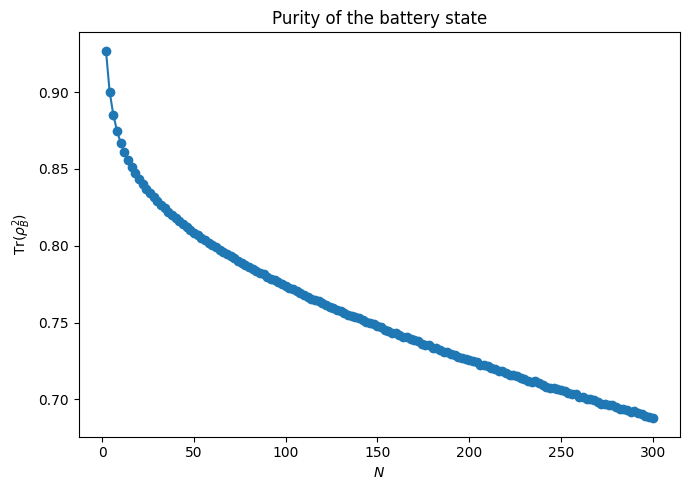

In [8]:
plt.figure(figsize=(7,5))
plt.plot(N_arr, purity, 'o-')
plt.xlabel(r'$N$')
plt.ylabel(r'$\mathrm{Tr}(\rho_B^2)$')
plt.title('Purity of the battery state')
plt.tight_layout()
plt.show()

### Scaling of $1 - \mathcal{E}_b / \langle E_b \rangle$

Best fit parameter: A = 0.043697, alpha = 0.702294


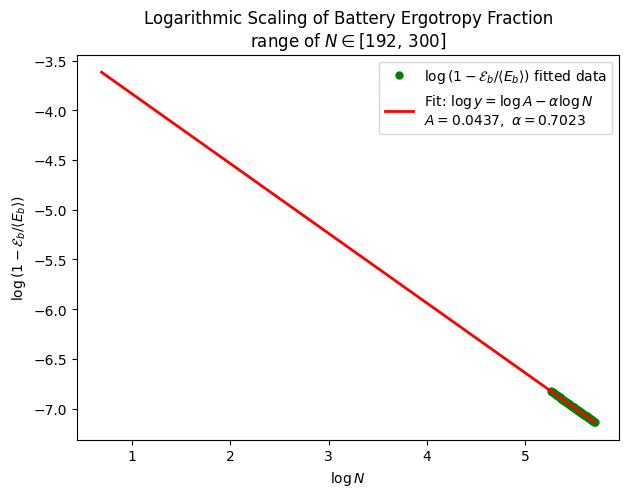

In [26]:
###################################
# Scaling using a logarithmic plot
###################################

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Fitting function in log-space
def log_fit1(log_N, logA, alpha1):
    return logA - alpha1 *log_N

y_full = 1 - np.array(E_ratio)

# Restrict fitting data
N_data1 = N_arr[95:150]
y_data1 = y_full[95:150]

# Keep only positive values for the logarithm
mask = (N_data1 > 0) & (y_data1 > 0)

N_fit1 = N_data1[mask]
y_fit_data1 = y_data1[mask]

# Logarithmic variables
log_N = np.log(N_fit1)
log_y = np.log(y_fit_data1)

# Fit in log-space
popt, pcov = curve_fit(log_fit1, log_N, log_y)

logA_opt, alpha_opt = popt

A_opt = np.exp(logA_opt)

print(f"Best fit parameter: A = {A_opt:.6f}, alpha = {alpha_opt:.6f}")

# Smooth curve over FULL N range
N_smooth = np.linspace(min(N_arr), max(N_arr), 300)

y_smooth = A_opt / (N_smooth**alpha_opt)

plt.figure(figsize=(7, 5))

# Plot FULL dataset with faded colours
# plt.plot(np.log(N_arr[y_full > 0]), np.log(y_full[y_full > 0]), 'o', color='y', markersize=5, alpha=0.5,label=r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$ data excluded")

# Plot restricted fitted data
plt.plot(log_N, log_y, 'o', color='g', markersize=5, label=r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$ fitted data")

# Plot fitted line over FULL range
plt.plot(np.log(N_smooth), np.log(y_smooth), '-', color='r', linewidth=2, label=(
        rf'Fit: $\log y = \log A - \alpha \log N$'
        '\n'
        rf'$A={A_opt:.4f},\ \alpha={alpha_opt:.4f}$'))

plt.xlabel(r"$\log N$")
plt.ylabel(r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$")
plt.title(
    rf"Logarithmic Scaling of Battery Ergotropy Fraction"
    "\n"
    rf"range of $N \in [{N_fit1[0]},\, {N_fit1[-1]}]$"
)
plt.legend()
plt.show()

Best fit parameter: A = 0.042823, alpha = 0.698672


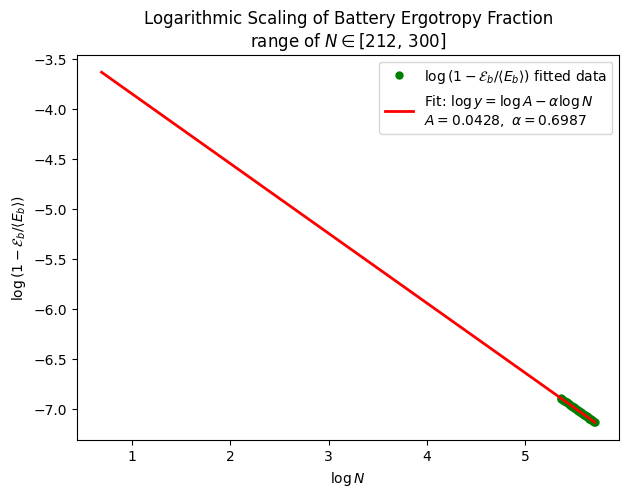

In [25]:
###################################
# Scaling using a logarithmic plot
###################################

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Fitting function in log-space
def log_fit1(log_N, logA, alpha1):
    return logA - alpha1 *log_N

y_full = 1 - np.array(E_ratio)

# Restrict fitting data
N_data1 = N_arr[105:150]
y_data1 = y_full[105:150]

# Keep only positive values for the logarithm
mask = (N_data1 > 0) & (y_data1 > 0)

N_fit1 = N_data1[mask]
y_fit_data1 = y_data1[mask]

# Logarithmic variables
log_N = np.log(N_fit1)
log_y = np.log(y_fit_data1)

# Fit in log-space
popt, pcov = curve_fit(log_fit1, log_N, log_y)

logA_opt, alpha_opt = popt

A_opt = np.exp(logA_opt)

print(f"Best fit parameter: A = {A_opt:.6f}, alpha = {alpha_opt:.6f}")

# Smooth curve over FULL N range
N_smooth = np.linspace(min(N_arr), max(N_arr), 300)

y_smooth = A_opt / (N_smooth**alpha_opt)

plt.figure(figsize=(7, 5))

# Plot FULL dataset with faded colours
# plt.plot(np.log(N_arr[y_full > 0]), np.log(y_full[y_full > 0]), 'o', color='y', markersize=5, alpha=0.5,label=r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$ data excluded")

# Plot restricted fitted data
plt.plot(log_N, log_y, 'o', color='g', markersize=5, label=r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$ fitted data")

# Plot fitted line over FULL range
plt.plot(np.log(N_smooth), np.log(y_smooth), '-', color='r', linewidth=2, label=(
        rf'Fit: $\log y = \log A - \alpha \log N$'
        '\n'
        rf'$A={A_opt:.4f},\ \alpha={alpha_opt:.4f}$'))

plt.xlabel(r"$\log N$")
plt.ylabel(r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$")
plt.title(
    rf"Logarithmic Scaling of Battery Ergotropy Fraction"
    "\n"
    rf"range of $N \in [{N_fit1[0]},\, {N_fit1[-1]}]$"
)
plt.legend()
plt.show()

Best fit parameter: A = 0.042210, alpha = 0.696101


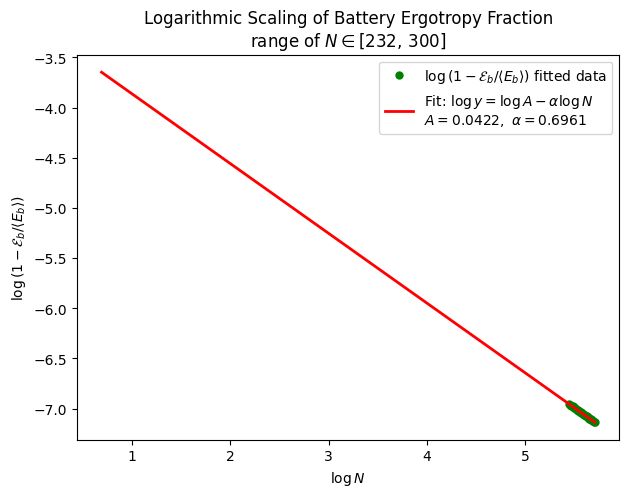

In [24]:
###################################
# Scaling using a logarithmic plot
###################################

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Fitting function in log-space
def log_fit1(log_N, logA, alpha1):
    return logA - alpha1 *log_N

y_full = 1 - np.array(E_ratio)

# Restrict fitting data
N_data1 = N_arr[115:150]
y_data1 = y_full[115:150]

# Keep only positive values for the logarithm
mask = (N_data1 > 0) & (y_data1 > 0)

N_fit1 = N_data1[mask]
y_fit_data1 = y_data1[mask]

# Logarithmic variables
log_N = np.log(N_fit1)
log_y = np.log(y_fit_data1)

# Fit in log-space
popt, pcov = curve_fit(log_fit1, log_N, log_y)

logA_opt, alpha_opt = popt

A_opt = np.exp(logA_opt)

print(f"Best fit parameter: A = {A_opt:.6f}, alpha = {alpha_opt:.6f}")

# Smooth curve over FULL N range
N_smooth = np.linspace(min(N_arr), max(N_arr), 300)

y_smooth = A_opt / (N_smooth**alpha_opt)

plt.figure(figsize=(7, 5))

# Plot FULL dataset with faded colours
# plt.plot(np.log(N_arr[y_full > 0]), np.log(y_full[y_full > 0]), 'o', color='y', markersize=5, alpha=0.5,label=r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$ data excluded")

# Plot restricted fitted data
plt.plot(log_N, log_y, 'o', color='g', markersize=5, label=r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$ fitted data")

# Plot fitted line over FULL range
plt.plot(np.log(N_smooth), np.log(y_smooth), '-', color='r', linewidth=2, label=(
        rf'Fit: $\log y = \log A - \alpha \log N$'
        '\n'
        rf'$A={A_opt:.4f},\ \alpha={alpha_opt:.4f}$'))

plt.xlabel(r"$\log N$")
plt.ylabel(r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$")
plt.title(
    rf"Logarithmic Scaling of Battery Ergotropy Fraction"
    "\n"
    rf"range of $N \in [{N_fit1[0]},\, {N_fit1[-1]}]$"
)
plt.legend()
plt.show()

Best fit parameter: A = 0.040675, alpha = 0.689530


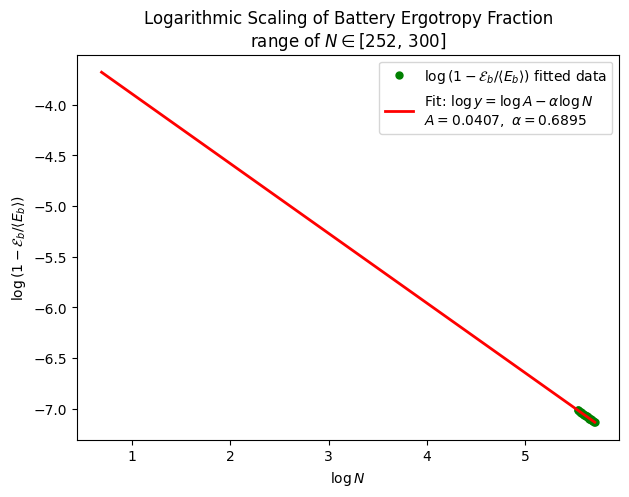

In [23]:
###################################
# Scaling using a logarithmic plot
###################################

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Fitting function in log-space
def log_fit1(log_N, logA, alpha1):
    return logA - alpha1 *log_N

y_full = 1 - np.array(E_ratio)

# Restrict fitting data
N_data1 = N_arr[125:150]
y_data1 = y_full[125:150]

# Keep only positive values for the logarithm
mask = (N_data1 > 0) & (y_data1 > 0)

N_fit1 = N_data1[mask]
y_fit_data1 = y_data1[mask]

# Logarithmic variables
log_N = np.log(N_fit1)
log_y = np.log(y_fit_data1)

# Fit in log-space
popt, pcov = curve_fit(log_fit1, log_N, log_y)

logA_opt, alpha_opt = popt

A_opt = np.exp(logA_opt)

print(f"Best fit parameter: A = {A_opt:.6f}, alpha = {alpha_opt:.6f}")

# Smooth curve over FULL N range
N_smooth = np.linspace(min(N_arr), max(N_arr), 300)

y_smooth = A_opt / (N_smooth**alpha_opt)

plt.figure(figsize=(7, 5))

# Plot FULL dataset with faded colours
# plt.plot(np.log(N_arr[y_full > 0]), np.log(y_full[y_full > 0]), 'o', color='y', markersize=5, alpha=0.5,label=r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$ data excluded")

# Plot restricted fitted data
plt.plot(log_N, log_y, 'o', color='g', markersize=5, label=r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$ fitted data")

# Plot fitted line over FULL range
plt.plot(np.log(N_smooth), np.log(y_smooth), '-', color='r', linewidth=2, label=(
        rf'Fit: $\log y = \log A - \alpha \log N$'
        '\n'
        rf'$A={A_opt:.4f},\ \alpha={alpha_opt:.4f}$'))

plt.xlabel(r"$\log N$")
plt.ylabel(r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$")
plt.title(
    rf"Logarithmic Scaling of Battery Ergotropy Fraction"
    "\n"
    rf"range of $N \in [{N_fit1[0]},\, {N_fit1[-1]}]$"
)
plt.legend()
plt.show()

Best fit parameter: A = 0.041199, alpha = 0.691787


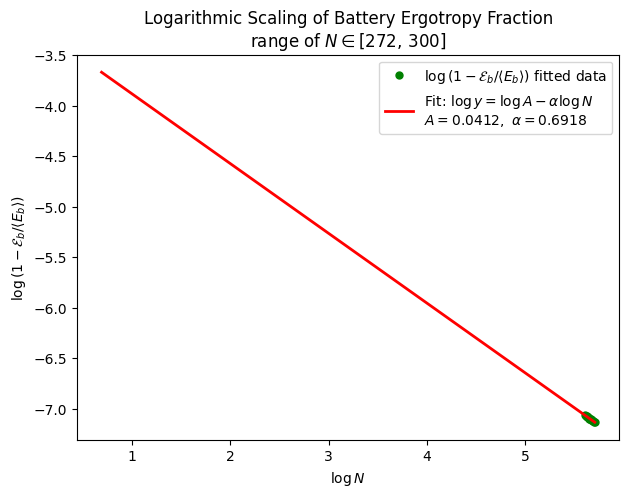

In [22]:
###################################
# Scaling using a logarithmic plot
###################################

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Fitting function in log-space
def log_fit1(log_N, logA, alpha1):
    return logA - alpha1 *log_N

y_full = 1 - np.array(E_ratio)

# Restrict fitting data
N_data1 = N_arr[135:150]
y_data1 = y_full[135:150]

# Keep only positive values for the logarithm
mask = (N_data1 > 0) & (y_data1 > 0)

N_fit1 = N_data1[mask]
y_fit_data1 = y_data1[mask]

# Logarithmic variables
log_N = np.log(N_fit1)
log_y = np.log(y_fit_data1)

# Fit in log-space
popt, pcov = curve_fit(log_fit1, log_N, log_y)

logA_opt, alpha_opt = popt

A_opt = np.exp(logA_opt)

print(f"Best fit parameter: A = {A_opt:.6f}, alpha = {alpha_opt:.6f}")

# Smooth curve over FULL N range
N_smooth = np.linspace(min(N_arr), max(N_arr), 300)

y_smooth = A_opt / (N_smooth**alpha_opt)

plt.figure(figsize=(7, 5))

# Plot FULL dataset with faded colours
# plt.plot(np.log(N_arr[y_full > 0]), np.log(y_full[y_full > 0]), 'o', color='y', markersize=5, alpha=0.5,label=r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$ data excluded")

# Plot restricted fitted data
plt.plot(log_N, log_y, 'o', color='g', markersize=5, label=r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$ fitted data")

# Plot fitted line over FULL range
plt.plot(np.log(N_smooth), np.log(y_smooth), '-', color='r', linewidth=2, label=(
        rf'Fit: $\log y = \log A - \alpha \log N$'
        '\n'
        rf'$A={A_opt:.4f},\ \alpha={alpha_opt:.4f}$'))

plt.xlabel(r"$\log N$")
plt.ylabel(r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$")
plt.title(
    rf"Logarithmic Scaling of Battery Ergotropy Fraction"
    "\n"
    rf"range of $N \in [{N_fit1[0]},\, {N_fit1[-1]}]$"
)
plt.legend()
plt.show()

Range [95:150]  -->  alpha = 0.702294
Range [105:150]  -->  alpha = 0.698672
Range [115:150]  -->  alpha = 0.696101
Range [125:150]  -->  alpha = 0.689530
Range [135:150]  -->  alpha = 0.691787


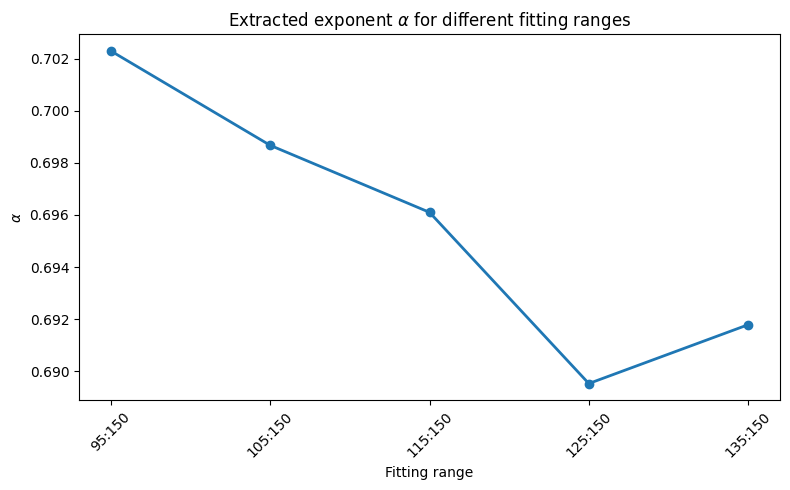

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def log_fit1(log_N, logA, alpha):
    return logA - alpha * log_N

y_full = 1 - np.array(E_ratio)

fit_ranges = [
    (95, 150),
    (105, 150),
    (115, 150),
    (125, 150),
    (135, 150)
]

alpha_list = []
range_labels = []

for start, end in fit_ranges:

    N_data = N_arr[start:end]
    y_data = y_full[start:end]

    mask = (N_data > 0) & (y_data > 0)

    N_fit = N_data[mask]
    y_fit = y_data[mask]

    if len(N_fit) < 3:
        continue

    log_N = np.log(N_fit)
    log_y = np.log(y_fit)

    popt, _ = curve_fit(log_fit1, log_N, log_y)

    alpha = popt[1]

    alpha_list.append(alpha)
    range_labels.append(f"{start}:{end}")

    print(f"Range [{start}:{end}]  -->  alpha = {alpha:.6f}")

# -----------------------------------
# Alpha vs fitting range
# -----------------------------------

plt.figure(figsize=(8,5))

plt.plot(range(len(alpha_list)), alpha_list, 'o-', lw=2)

plt.xticks(range(len(range_labels)), range_labels, rotation=45)

plt.xlabel("Fitting range")
plt.ylabel(r"$\alpha$")
plt.title(r"Extracted exponent $\alpha$ for different fitting ranges")
plt.tight_layout()
plt.show()

### Scaling of $\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$

Best fit parameter: A = 1.003285, alpha = 0.554234


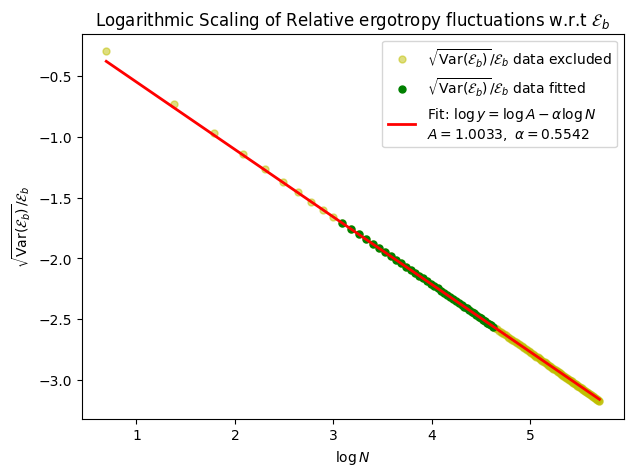

In [ ]:
###################################
# Scaling using a logarithmic plot
###################################

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Fitting function in log-space
def log_fit2(log_N, logA, alpha2):
    return logA - alpha2 *log_N

y_full = np.array(F_ratio)

# Restrict fitting data
N_data2 = N_arr[10:51]
y_data2 = y_full[10:51]

# Keep only positive values for the logarithm
mask = (N_data2 > 0) & (y_data2 > 0)

N_fit2 = N_data2[mask]
y_fit_data2 = y_data2[mask]

# Logarithmic variables
log_N = np.log(N_fit2)
log_y = np.log(y_fit_data2)

# Fit in log-space
popt, pcov = curve_fit(log_fit2, log_N, log_y)

logA_opt, alpha_opt = popt

A_opt = np.exp(logA_opt)

print(f"Best fit parameter: A = {A_opt:.6f}, alpha = {alpha_opt:.6f}")

# Smooth curve over FULL N range
N_smooth = np.linspace(min(N_arr), max(N_arr), 300)

y_smooth = A_opt / (N_smooth**alpha_opt)

plt.figure(figsize=(7, 5))

# Plot FULL dataset with faded colours
plt.plot(np.log(N_arr[y_full > 0]), np.log(y_full[y_full > 0]), 'o', color='y', markersize=5, alpha=0.5,label=r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$ data excluded")

# Plot restricted fitted data
plt.plot(log_N, log_y, 'o', color='g', markersize=5, label=r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$ data fitted")

# Plot fitted line over FULL range
plt.plot(np.log(N_smooth), np.log(y_smooth), '-', color='r', linewidth=2, label=(
        rf'Fit: $\log y = \log A - \alpha \log N$'
        '\n'
        rf'$A={A_opt:.4f},\ \alpha={alpha_opt:.4f}$'))

plt.xlabel(r"$\log N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Logarithmic Scaling of Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
plt.legend()
plt.show()